Retrieving InsertionElectrodeDoc documents: 100%|██████████| 2085/2085 [00:00<00:00, 7623.16it/s] 


average_voltage: 3.8091562666892944
energy_grav: 506.62442691312776
energy_vol: 1724.4262997343055
capacity_grav: 134.9065620456155
capacity_vol: 462.72711422557285
max_delta_volume: 0.04603199015055506
stability_charge: 0.060126723650386696
stability_discharge: 0.04426661521581602
fracA_charge: 0.047209882016100914
fracA_discharge: 0.157640674397867
2085


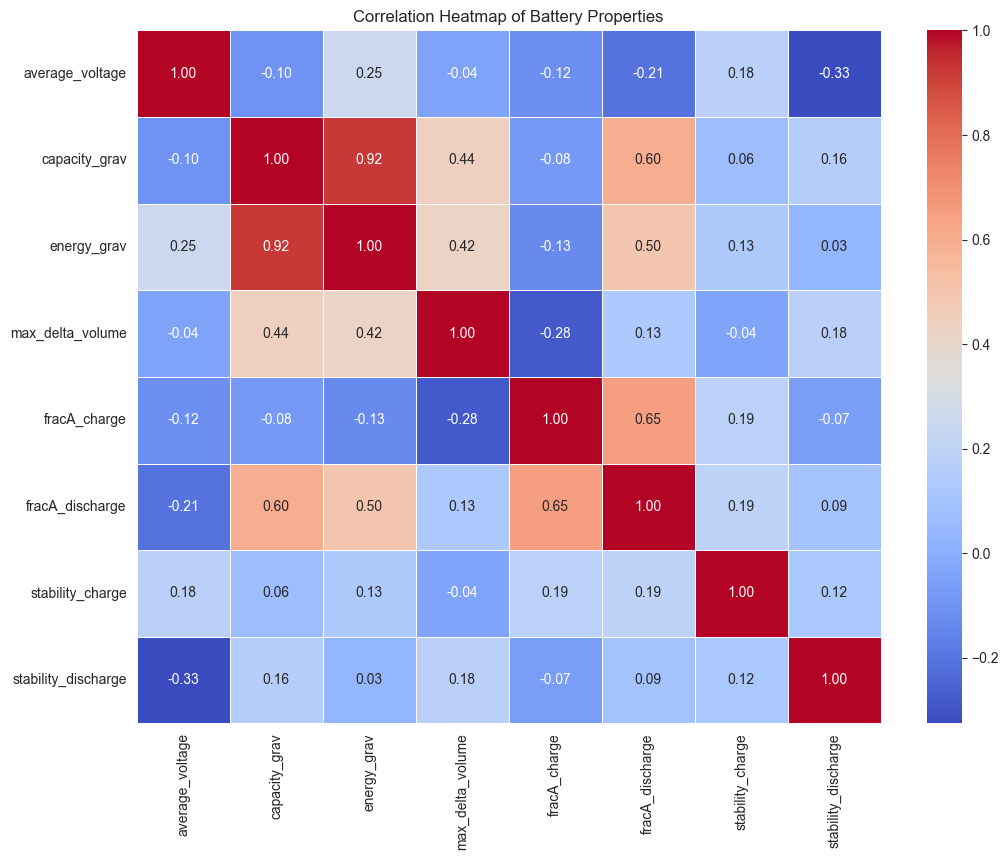


Data Size: 2085


In [7]:
# LITHIUM

from mp_api.client import MPRester
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
API_KEY = "4IeHY5jVcrgiKXNuAo6Jgs7yC0Z3hsli"
try:
    with MPRester(API_KEY) as mpr:
        # Query for Li-based cathode materials with high energy density
        docs = mpr.materials.insertion_electrodes.search(
        working_ion="Li",
        average_voltage = (2.5, 8.0), stability_charge=(0.0, 0.15), # 0.1 > stability_charge (meV) starts to be unstable
        fields=[
            "battery_id", "formula_discharge", "average_voltage"
            , "energy_grav", "energy_vol", "capacity_grav", "capacity_vol", "stability_charge", "fracA_charge", "max_delta_volume", "stability_discharge", "fracA_discharge"
        ])

        Fields = "average_voltage", "energy_grav", "energy_vol", "capacity_grav", "capacity_vol", "max_delta_volume", "stability_charge", "stability_discharge", "fracA_charge", "fracA_discharge"

        def average_field(docs, field):
            vals = [getattr(d, field) for d in docs if getattr(d, field) is not None]
            return sum(vals) / len(vals)


        df = pd.DataFrame([doc.dict() for doc in docs])
        df.head(20)

        for f in Fields:
            avg = average_field(docs, f)
            print(f"{f}: {avg}")
        print(len(df))
        df.head(20)

         # Select only the numeric columns relevant to battery performance
    cols_to_analyze = ['average_voltage', 'capacity_grav', 'energy_grav',
                        'max_delta_volume',
                       'fracA_charge', 'fracA_discharge', 'stability_charge', 'stability_discharge']
    correlation_matrix = (df[cols_to_analyze].corr(method="spearman"))
    correlation_matrix.head()
    plt.figure(figsize=(12, 9))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title("Correlation Heatmap of Battery Properties")
    plt.show()
    print(f"\nData Size: {len(df)}")



except Exception as e:
    print(f"An error occurred: {e}")




mp-19308_Li: 512.583049076424
mp-35925_Li: 512.583049076424
mp-758670_Li: 482.1667264629809
mp-759184_Li: 482.1667264629809
mp-759539_Li: 482.1667264629809
mp-1111688_Li: 430.4087060467724
mp-850895_Li: 194.46995190364947
mp-22417_Li: 166.87745702027735
mp-25304_Li: 166.87745702027735
mp-26387_Li: 166.87745702027735
mp-752757_Li: 121.92721344604827
mp-752923_Li: 121.92721344604827
mp-756285_Li: 121.92721344604827
mp-759520_Li: 121.92721344604827
mp-759829_Li: 121.92721344604827
mp-761130_Li: 121.92721344604827
mp-764367_Li: 121.92721344604827
mp-775438_Li: 121.92721344604827
mp-779058_Li: 121.92721344604827
mp-26347_Li: 87.38500473947427
mp-26531_Li: 69.26372881094476


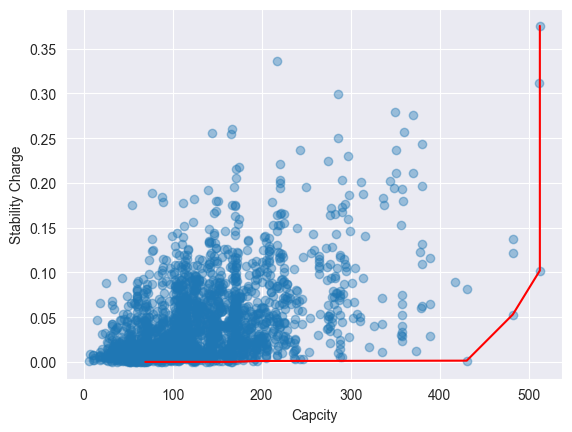

In [13]:
import matplotlib.pyplot as plt

"""
Capacity VS Max Delta Volume
"""

capacity = [doc.capacity_grav for doc in docs if doc.capacity_grav is not None]
maxChangeInVolume = [doc.max_delta_volume for doc in docs if doc.max_delta_volume is not None]

def plot_pareto_frontier(Xs, Ys, maxX=True, maxY=False, xlabel='Capacity', ylabel='Change in Volume Charge',):
    '''Pareto frontier selection process
    :param Xs: Series of X values
    :param Ys: Series of Y values
    :param maxX: True if maximizing on X
    :param maxY: True if maximizing on Y
    :param xlabel: plot label for X
    :parma ylabel: plot label for Y
    '''
    n = 0
    sorted_list = sorted([[Xs[i], Ys[i]] for i in range(len(Xs))], reverse=maxX) # Sorts values (descending if reverse = True)
    pareto_front = [sorted_list[0]]
    battery_ids = []
    for pair in sorted_list[1:]:
        if maxY:
            if pair[1] >= pareto_front[-1][1]:
                pareto_front.append(pair)
                for id in docs:
                    if id.capacity_grav == pair[0] or id.max_delta_volume == pair[0]:
                        print(f"{id.battery_id}: {pair[0]} mAh/g") # Print ID and voltage

        else:
            if pair[1] <= pareto_front[-1][1]:
                pareto_front.append(pair)
                for id in docs:
                    if id.capacity_grav == pair[0] or id.max_delta_volume == pair[0]:
                        print(f"{id.battery_id}: {pair[0]}") # Print ID and voltage


    '''Plotting process'''
    plt.scatter(Xs,Ys, alpha=0.4)
    pf_X = [pair[0] for pair in pareto_front]
    pf_Y = [pair[1] for pair in pareto_front]
    plt.plot(pf_X, pf_Y, color='red')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

    #return pareto_front

plot_pareto_frontier(capacity, maxChangeInVolume)


mp-19308_Li: 512.583049076424
mp-35925_Li: 512.583049076424
mp-32686_Li: 511.41035403457124
mp-1111688_Li: 430.4087060467724
mp-27309_Li: 335.40524494960664
mp-752600_Li: 335.40524494960664
mp-765646_Li: 335.40524494960664
mp-25403_Li: 299.80414659784276
mp-21633_Li: 288.5681979329664
mp-753390_Li: 288.5681979329664
mp-753571_Li: 288.5681979329664
mp-753667_Li: 288.5681979329664
mp-759464_Li: 288.5681979329664
mp-777681_Li: 288.5681979329664
mp-752752_Li: 282.49037506361327
mp-555112_Li: 276.65970915616407
mp-17754_Li: 272.52168764444093
mp-541384_Li: 225.46077143068698
mp-754676_Li: 225.46077143068698
mp-764783_Li: 225.46077143068698
mp-18911_Li: 224.49920551243662
mp-26727_Li: 224.49920551243662
mp-705024_Li: 224.49920551243662
mp-26379_Li: 220.80333829412203
mp-26555_Li: 220.80333829412203
mp-26734_Li: 220.80333829412203
mp-26981_Li: 220.80333829412203
mp-540033_Li: 220.80333829412203
mp-755561_Li: 220.80333829412203
mp-770531_Li: 220.80333829412203
mp-770558_Li: 220.80333829412203


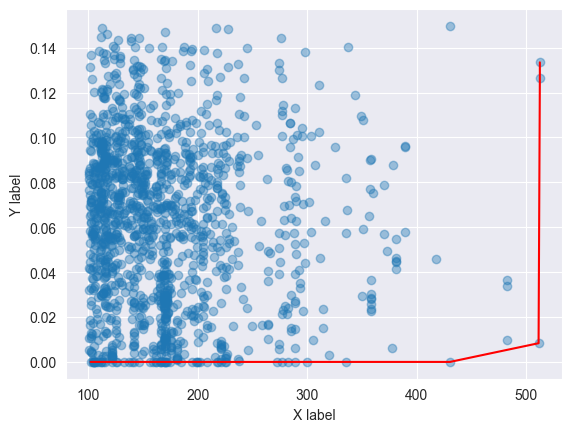

In [14]:
import matplotlib.pyplot as plt

capacity = [doc.capacity_grav for doc in docs if doc.capacity_grav is not None and doc.capacity_grav > 100]
instabilities = [doc.stability_charge for doc in docs if doc.stability_charge is not None and doc.capacity_grav > 100]

def plot_pareto_frontier(Xs, Ys, maxX=True, maxY=False, xlabel='X label', ylabel='Y label'):
    '''Pareto frontier selection process
    :param Xs: Series of X values
    :param Ys: Series of Y values
    :param maxX: True if maximizing on X
    :param maxY: True if maximizing on Y
    :param xlabel: plot label for X
    :parma ylabel: plot label for Y
    '''
    n = 0
    sorted_list = sorted([[Xs[i], Ys[i]] for i in range(len(Xs))], reverse=maxX) # Sorts values (descending if reverse = True)
    pareto_front = [sorted_list[0]]
    battery_ids = []
    for pair in sorted_list[1:]:
        if maxY:
            if pair[1] >= pareto_front[-1][1]:
                pareto_front.append(pair)
                for id in docs:
                    if id.capacity_grav == pair[0] or id.stability_charge == pair[0]:
                        print(f"{id.battery_id}: {pair[0]}V") # Print ID and voltage
                        n+=1

        else:
            if pair[1] <= pareto_front[-1][1]:
                pareto_front.append(pair)
                for id in docs:
                    if id.capacity_grav == pair[0] or id.stability_charge == pair[0]:
                        print(f"{id.battery_id}: {pair[0]}") # Print ID and voltage
                        n+=1

    print(f"On Pareto Front: {n}")
    '''Plotting process'''
    plt.scatter(Xs,Ys, alpha=0.4)
    pf_X = [pair[0] for pair in pareto_front]
    pf_Y = [pair[1] for pair in pareto_front]
    plt.plot(pf_X, pf_Y, color='red')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

    #return pareto_front

plot_pareto_frontier(capacity, instabilities)


mp-19308_Li: 512.583049076424
mp-35925_Li: 512.583049076424
mp-32686_Li: 511.41035403457124
mp-758670_Li: 482.1667264629809
mp-759184_Li: 482.1667264629809
mp-759539_Li: 482.1667264629809
mp-758670_Li: 482.1667264629809
mp-759184_Li: 482.1667264629809
mp-759539_Li: 482.1667264629809
mp-758670_Li: 482.1667264629809
mp-759184_Li: 482.1667264629809
mp-759539_Li: 482.1667264629809
mp-25323_Li: 430.787772220729
mp-1111688_Li: 430.4087060467724
mp-752577_Li: 388.93990380729895
mp-757787_Li: 388.93990380729895
mp-761177_Li: 388.93990380729895
mp-752577_Li: 388.93990380729895
mp-757787_Li: 388.93990380729895
mp-761177_Li: 388.93990380729895
mp-752577_Li: 388.93990380729895
mp-757787_Li: 388.93990380729895
mp-761177_Li: 388.93990380729895
mp-752499_Li: 380.65659226275363
mp-753053_Li: 380.65659226275363
mp-755801_Li: 380.65659226275363
mp-759217_Li: 380.65659226275363
mp-759972_Li: 380.65659226275363
mp-752499_Li: 380.65659226275363
mp-753053_Li: 380.65659226275363
mp-755801_Li: 380.65659226275

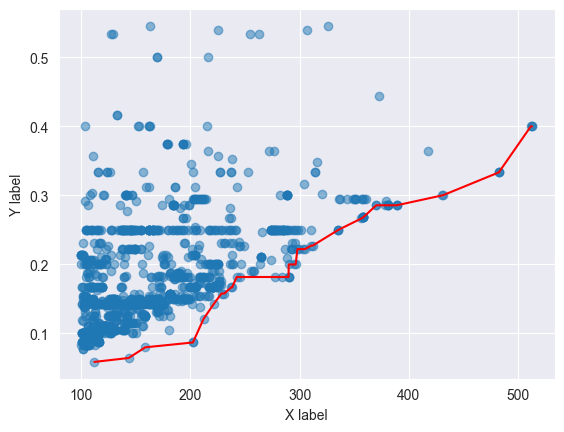

In [19]:
import matplotlib.pyplot as plt

capacity = [doc.capacity_grav for doc in docs if doc.capacity_grav is not None and doc.capacity_grav > 100]
fracA_Discharge = [doc.fracA_discharge for doc in docs if doc.fracA_discharge is not None and doc.capacity_grav > 100]

def plot_pareto_frontier(Xs, Ys, maxX=True, maxY=False, xlabel='X label', ylabel='Y label'):
    '''Pareto frontier selection process
    :param Xs: Series of X values
    :param Ys: Series of Y values
    :param maxX: True if maximizing on X
    :param maxY: True if maximizing on Y
    :param xlabel: plot label for X
    :parma ylabel: plot label for Y
    '''
    n = 0
    sorted_list = sorted([[Xs[i], Ys[i]] for i in range(len(Xs))], reverse=maxX) # Sorts values (descending if reverse = True)
    pareto_front = [sorted_list[0]]
    battery_ids = []
    for pair in sorted_list[1:]:
        if maxY:
            if pair[1] >= pareto_front[-1][1]:
                pareto_front.append(pair)
                for id in docs:
                    if id.capacity_grav == pair[0] or id.fracA_discharge == pair[0]:
                        print(f"{id.battery_id}: {pair[0]} mAh/g") # Print ID and voltage
                        n+=1

        else:
            if pair[1] <= pareto_front[-1][1]:
                pareto_front.append(pair)
                for id in docs:
                    if id.capacity_grav == pair[0] or id.fracA_discharge == pair[0]:
                        print(f"{id.battery_id}: {pair[0]}") # Print ID and voltage
                        n+=1

    print(f"On Pareto Front: {n}")
    '''Plotting process'''
    plt.scatter(Xs,Ys, alpha=0.5)
    pf_X = [pair[0] for pair in pareto_front]
    pf_Y = [pair[1] for pair in pareto_front]
    plt.plot(pf_X, pf_Y, color='red')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

    #return pareto_front

plot_pareto_frontier(capacity, fracA_Discharge)
